# **Laboratorio 4 - Visión por Computadora**

- Paula Barillas - 22764
- Gerardo Pineda - 22880
- Mónica Salvatierra - 22249

Link del repositorio: https://github.com/alee2602/LAB4-VPC

## **Task 1**



**1. Una homografía 𝐻 es una matriz de 3 × 3. Explique matemáticamente por qué, aunque tiene 9 elementos, solo posee 8 grados de libertad (GDL)**

<img src="img/IMG_3711.jpg" width="800">


- Una homografía H∈R 3×3 tiene 9 parámetros, pero está definida en coordenadas homogéneas. En este espacio, dos matrices que difieren por un factor escalar no nulo representan la misma transformación proyectiva, es decir, H∼αH para cualquier 𝛼≠0. Por esta razón, uno de los 9 parámetros es redundante (la escala global), y por tanto la homografía posee únicamente 8 grados de libertad como tal.

    **1.1. Adicionalmente, respoda. Si tuviéramos una cámara que solo rota sobre su eje óptico (sin traslación ni cambio de perspectiva), ¿la matriz de transformación sigue teniendo 8 GDL o se reduce? Demuestre la estructura de dicha matriz simplificada**

    <img src="img/IMG_3712.jpg" width="800">


- Si la cámara únicamente rota alrededor de su eje óptico y no existe traslación ni cambio de perspectiva, la transformación entre imágenes se reduce a una rotación en el plano. En este caso, la homografía depende únicamente del ángulo de rotación θ. Por lo tanto, los grados de libertad ya no son 8, sino que se reducen a 1, correspondiente al parámetro del ángulo.


**2. En el algoritmo DLT (Direct Linear Transform), convertimos el problema 𝑥′ = 𝐻𝑥 en un sistema de la forma 𝐴ℎ = 0. Explique por qué buscamos el vector singular asociado al menor valor singular de 𝐴 en lugar de simplemente invertir la matriz. ¿Qué representa geométricamente ese "menor valor singular" cuando los datos tienen ruido?**

<img src="img/IMG_3713.jpg" width="800">

<img src="img/IMG_3714.jpg" width="800">

- No se invierte 𝐴 porque el sistema es homogéneo y rectangular, por lo que no es invertible y con ruido solo tendría la solución trivial. Por eso se plantea como un problema de minimización.

- El menor valor singular representa el mínimo error residual posible, indicando qué tan cerca está el sistema de tener una solución exacta y que tan consistentes son los datos.


**3. Si usted selecciona 4 puntos para calcular 𝐻, pero 3 de ellos son colineales (están en la misma línea recta), el algoritmo fallará. Explique algebraicamente qué le sucede a la matriz 𝐴 del sistema DLT en este caso y por qué no tiene solución única.**

- Si tres puntos son colineales, las restricciones que generan en el sistema DLT no son linealmente independientes. Esto provoca que la matriz 𝐴 pierda rango, y por tanto su espacio nulo tenga dimensión mayor a uno. Como consecuencia, existen múltiples soluciones posibles para la homografía y el sistema no tiene una solución única. Esta configuración se considera degenerada para el cálculo de 𝐻.

# TASK 2

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

In [11]:
img1 = cv2.imread("img/DB/1.jpeg")
img2 = cv2.imread("img/DB/2.jpeg")
img3 = cv2.imread("img/DB/3.jpeg")

img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
img3_gray = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)

In [3]:
sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(img1_gray, None)
kp2, des2 = sift.detectAndCompute(img2_gray, None)

In [4]:
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(des1, des2)

matches = sorted(matches, key=lambda x: x.distance)

## Deteccion

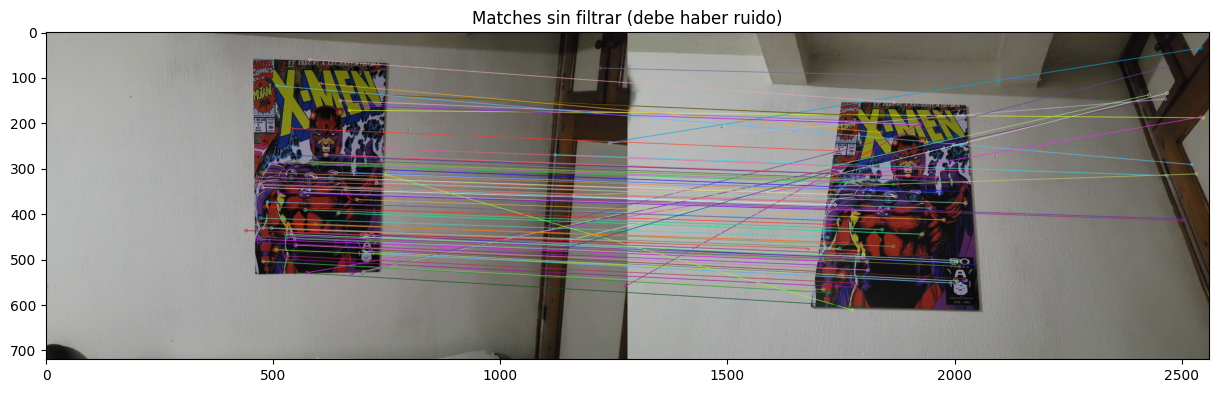

In [ ]:
img_matches = cv2.drawMatches(
    img1, kp1,
    img2, kp2,
    matches[:100], 
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(15,8))
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title("Matches sin filtrar (debe haber ruido)")
plt.show()

## DLT MANUAL

In [6]:
def normalizar_puntos(puntos):
    mean = np.mean(puntos, axis=0)
    std = np.std(puntos)

    T = np.array([
        [1/std, 0, -mean[0]/std],
        [0, 1/std, -mean[1]/std],
        [0, 0, 1]
    ])

    puntos_h = np.hstack((puntos, np.ones((puntos.shape[0],1))))
    puntos_norm = (T @ puntos_h.T).T

    return puntos_norm, T

In [ ]:
def calcular_homografia_dlt(puntos_src, puntos_dst):

    src_norm, T_src = normalizar_puntos(puntos_src)
    dst_norm, T_dst = normalizar_puntos(puntos_dst)

    A = []

    for i in range(4):
        x, y, _ = src_norm[i]
        xp, yp, _ = dst_norm[i]

        A.append([-x, -y, -1, 0, 0, 0, x*xp, y*xp, xp])
        A.append([0, 0, 0, -x, -y, -1, x*yp, y*yp, yp])

    A = np.array(A)

    # SVD
    U, S, Vt = np.linalg.svd(A)
    H_norm = Vt[-1].reshape(3,3)

    # Desnormalizar
    H = np.linalg.inv(T_dst) @ H_norm @ T_src

    return H / H[2,2]

In [ ]:
def ransac_homografia(matches, kp1, kp2, umbral=5, prob_exito=0.99):

    mejor_H = None
    mejor_inliers = []
    max_inliers = 0

    w = 0.5  
    s = 4    

    N = int(np.log(1 - prob_exito) / np.log(1 - w**s))

    for i in range(N):

        sample = random.sample(matches, 4)

        pts_src = np.float32([kp1[m.queryIdx].pt for m in sample])
        pts_dst = np.float32([kp2[m.trainIdx].pt for m in sample])

        H_test = calcular_homografia_dlt(pts_src, pts_dst)

        inliers = []

        for m in matches:
            pt_src = np.array([*kp1[m.queryIdx].pt, 1])
            pt_dst = np.array(kp2[m.trainIdx].pt)

            proyectado = H_test @ pt_src
            proyectado /= proyectado[2]

            error = np.linalg.norm(proyectado[:2] - pt_dst)

            if error < umbral:
                inliers.append(m)

        if len(inliers) > max_inliers:
            max_inliers = len(inliers)
            mejor_inliers = inliers
            mejor_H = H_test

            w = max_inliers / len(matches)
            N = int(np.log(1 - prob_exito) / np.log(1 - w**s))


    if len(mejor_inliers) >= 4:

        pts_src = np.float32([kp1[m.queryIdx].pt for m in mejor_inliers])
        pts_dst = np.float32([kp2[m.trainIdx].pt for m in mejor_inliers])

        A = []
        src_norm, T_src = normalizar_puntos(pts_src)
        dst_norm, T_dst = normalizar_puntos(pts_dst)

        for i in range(len(mejor_inliers)):
            x, y, _ = src_norm[i]
            xp, yp, _ = dst_norm[i]

            A.append([-x, -y, -1, 0, 0, 0, x*xp, y*xp, xp])
            A.append([0, 0, 0, -x, -y, -1, x*yp, y*yp, yp])

        A = np.array(A)

        U, S, Vt = np.linalg.svd(A)
        H_norm = Vt[-1].reshape(3,3)
        mejor_H = np.linalg.inv(T_dst) @ H_norm @ T_src
        mejor_H /= mejor_H[2,2]

    return mejor_H, mejor_inliers

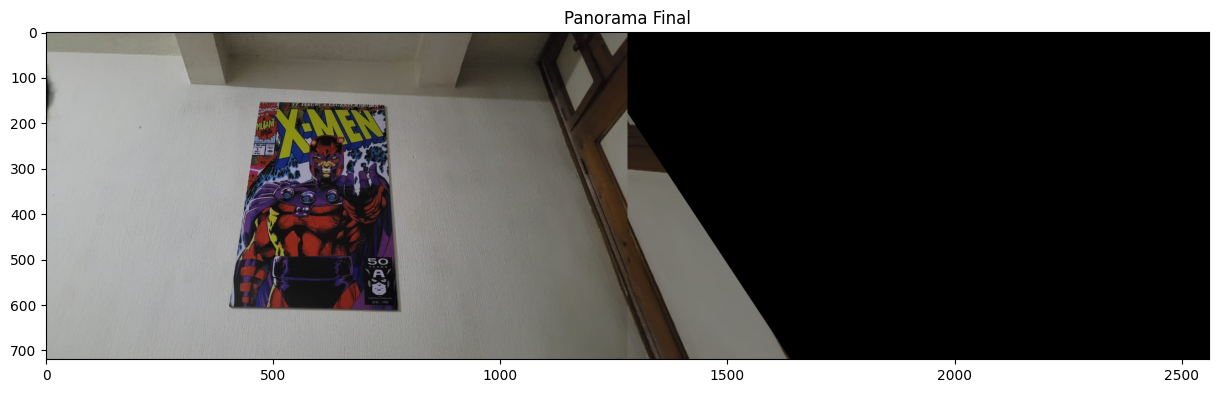

In [ ]:
H, inliers = ransac_homografia(matches, kp1, kp2)

altura, ancho = img2.shape[:2]

resultado = cv2.warpPerspective(img1, H, (ancho*2, altura))
resultado[0:altura, 0:ancho] = img2

plt.figure(figsize=(15,8))
plt.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
plt.title("Panorama Final")
plt.show()

In [12]:
H12, inliers12 = ransac_homografia(matches, kp1, kp2)

h2, w2 = img2.shape[:2]

panorama12 = cv2.warpPerspective(img1, H12, (w2*2, h2))
panorama12[0:h2, 0:w2] = img2

pan_gray = cv2.cvtColor(panorama12, cv2.COLOR_BGR2GRAY)
img3_gray = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)

kp_pan, des_pan = sift.detectAndCompute(pan_gray, None)
kp3, des3 = sift.detectAndCompute(img3_gray, None)

bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches23 = bf.match(des_pan, des3)
matches23 = sorted(matches23, key=lambda x: x.distance)

In [13]:
H23, inliers23 = ransac_homografia(matches23, kp_pan, kp3)

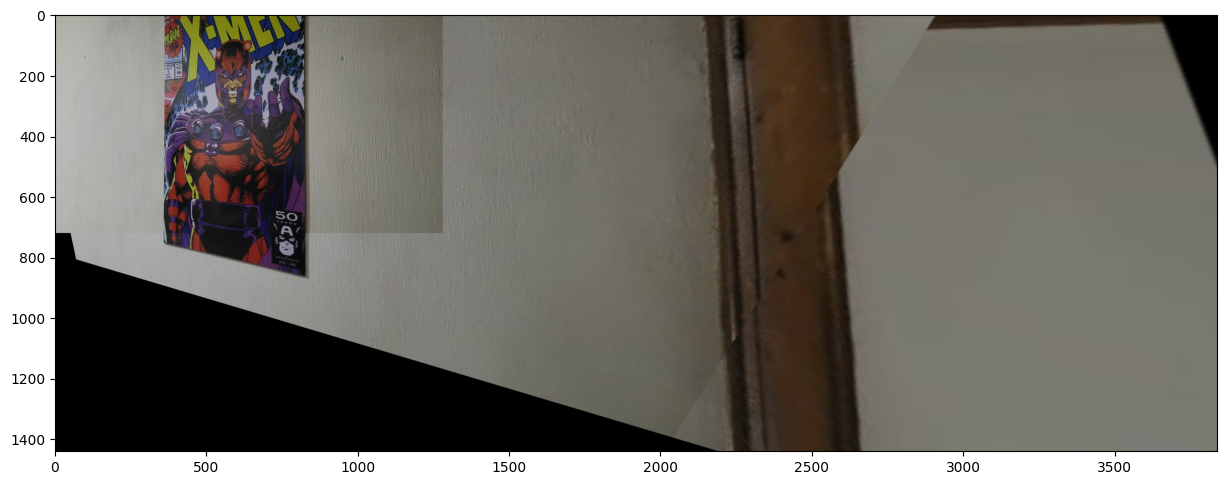

In [14]:
h3, w3 = img3.shape[:2]

panorama_final = cv2.warpPerspective(panorama12, H23, (w3*3, h3*2))
panorama_final[0:h3, 0:w3] = img3

plt.figure(figsize=(15,8))
plt.imshow(cv2.cvtColor(panorama_final, cv2.COLOR_BGR2RGB))
plt.show()

* como funciona RANSAC y cuales son los pasos que se tienen que hacer para hacerlo manual?
* Por que la imagen de panorama sale asi (imagen 2) jaja